In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

import warnings
warnings.filterwarnings("ignore")

In [7]:
!mkdir -p data
!wget -O data/creditcard.csv "YOUR_DIRECT_LINK"

--2026-09-24 06:05:50--  http://your_direct_link/
Resolving your_direct_link (your_direct_link)... failed: Name or service not known.
wget: unable to resolve host address ‘your_direct_link’


In [10]:
!pip install -q kagglehub
import kagglehub
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
DATA_PATH = f"{path}/creditcard.csv"
df = pd.read_csv(DATA_PATH)

Using Colab cache for faster access to the 'creditcardfraud' dataset.


In [12]:
df.shape[0]

284807

In [13]:
df.shape[1]

31

In [14]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [15]:
print(df.columns.tolist())

['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [16]:
pd.set_option("display.max_columns", None)

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


In [17]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

,0


In [18]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 1081


In [19]:
duplicate_percentage = (
    duplicate_count / len(df) * 100
)

print(f"Duplicate percentage: {duplicate_percentage:.4f}%")

Duplicate percentage: 0.3796%


In [21]:
print(df["Class"].value_counts())

Class
0    284315
1       492
Name: count, dtype: int64


In [22]:
print(df["Class"].value_counts(normalize=True) * 100)

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


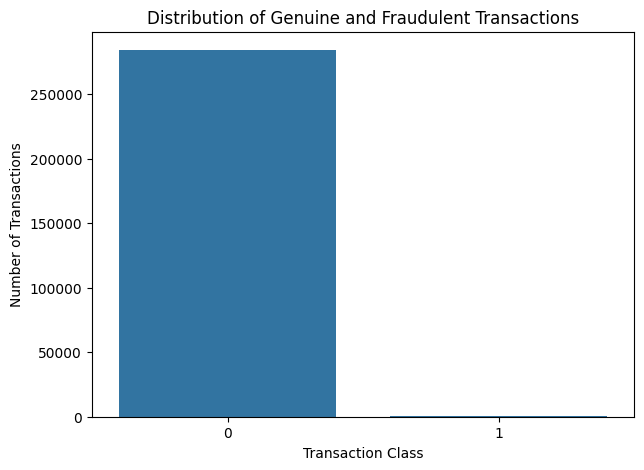

In [23]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Class"
)

plt.title("Distribution of Genuine and Fraudulent Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")

plt.show()

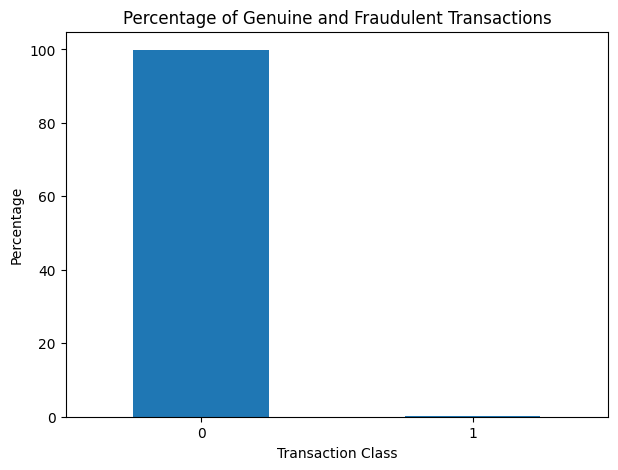

In [24]:
class_percentage = df["Class"].value_counts(normalize=True) * 100

plt.figure(figsize=(7, 5))

class_percentage.plot(kind="bar")

plt.title("Percentage of Genuine and Fraudulent Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Percentage")

plt.xticks(rotation=0)

plt.show()

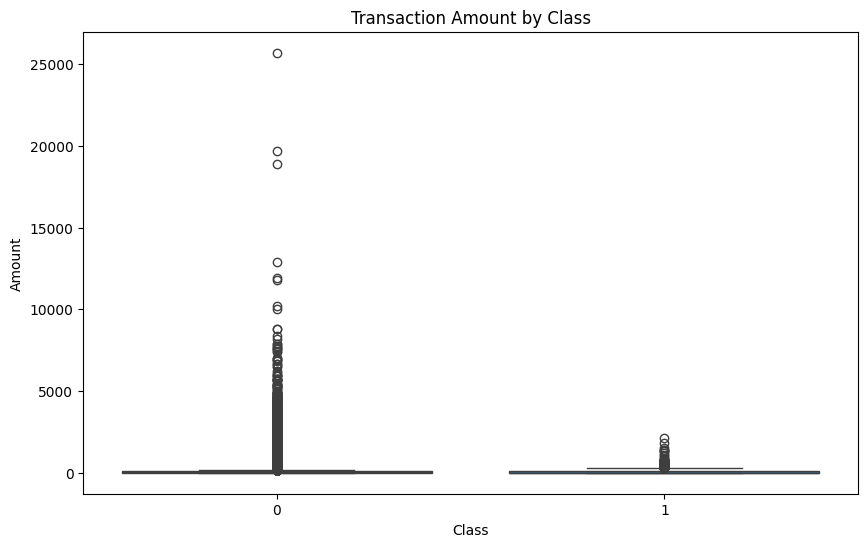

In [25]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Class",
    y="Amount"
)

plt.title("Transaction Amount by Class")
plt.xlabel("Class")
plt.ylabel("Amount")

plt.show()

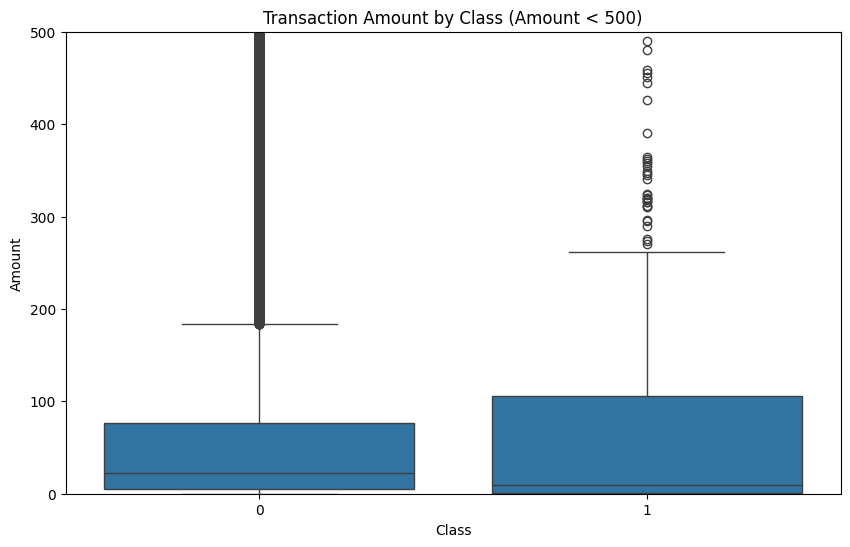

In [26]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Class",
    y="Amount"
)

plt.ylim(0, 500)

plt.title("Transaction Amount by Class (Amount < 500)")
plt.xlabel("Class")
plt.ylabel("Amount")

plt.show()

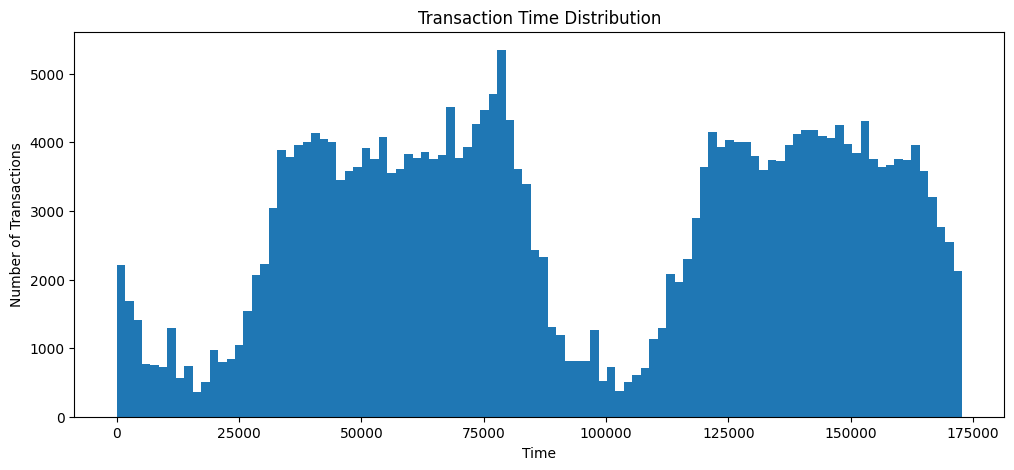

In [28]:
df["Time"].describe()
plt.figure(figsize=(12, 5))

plt.hist(
    df["Time"],
    bins=100
)

plt.title("Transaction Time Distribution")
plt.xlabel("Time")
plt.ylabel("Number of Transactions")

plt.show()

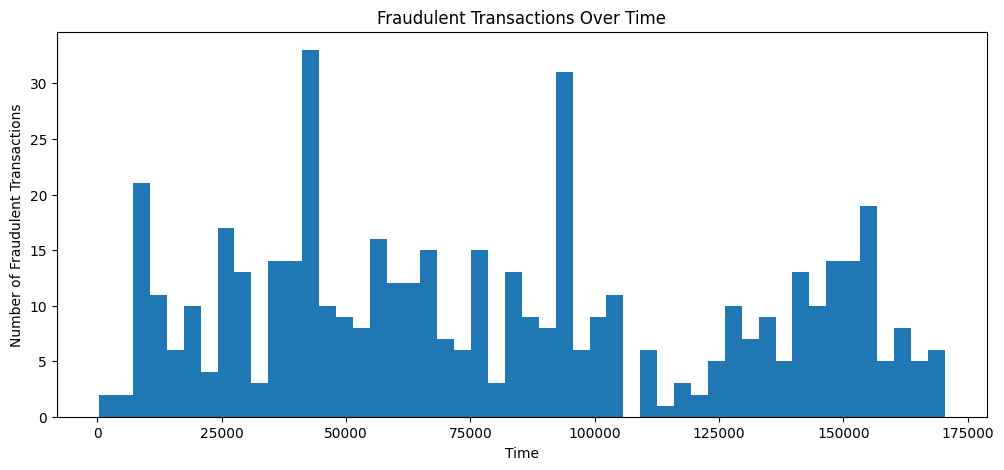

In [29]:
fraud = df[df["Class"] == 1]

plt.figure(figsize=(12, 5))

plt.hist(
    fraud["Time"],
    bins=50
)

plt.title("Fraudulent Transactions Over Time")
plt.xlabel("Time")
plt.ylabel("Number of Fraudulent Transactions")

plt.show()

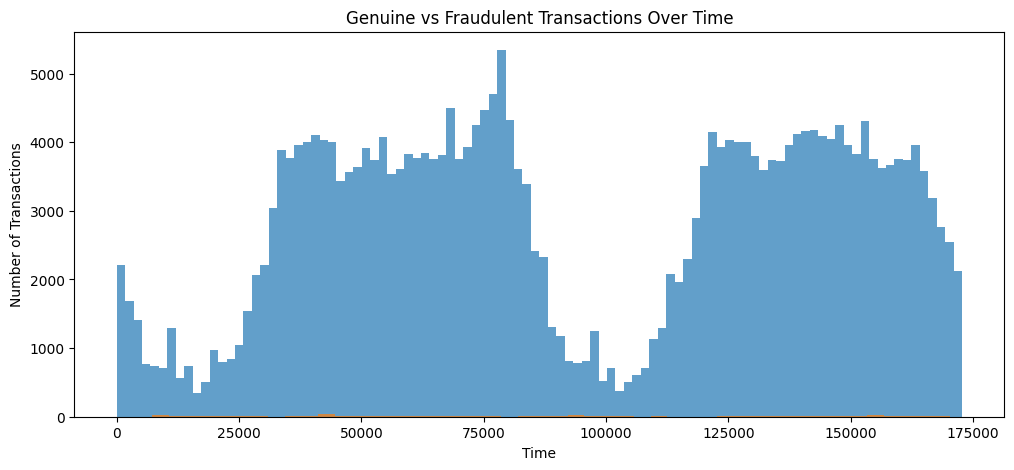

In [30]:
genuine = df[df["Class"] == 0]

plt.figure(figsize=(12, 5))

plt.hist(
    genuine["Time"],
    bins=100,
    alpha=0.7
)

plt.hist(
    fraud["Time"],
    bins=50,
    alpha=0.7
)

plt.title("Genuine vs Fraudulent Transactions Over Time")
plt.xlabel("Time")
plt.ylabel("Number of Transactions")

plt.show()

In [31]:
correlation = df.corr()

correlation["Class"].sort_values(ascending=False)

,Class
Class,1.000000
V11,0.154876
V4,0.133447
V2,0.091289
V21,0.040413
V19,0.034783
V20,0.020090
V8,0.019875
V27,0.017580
V28,0.009536


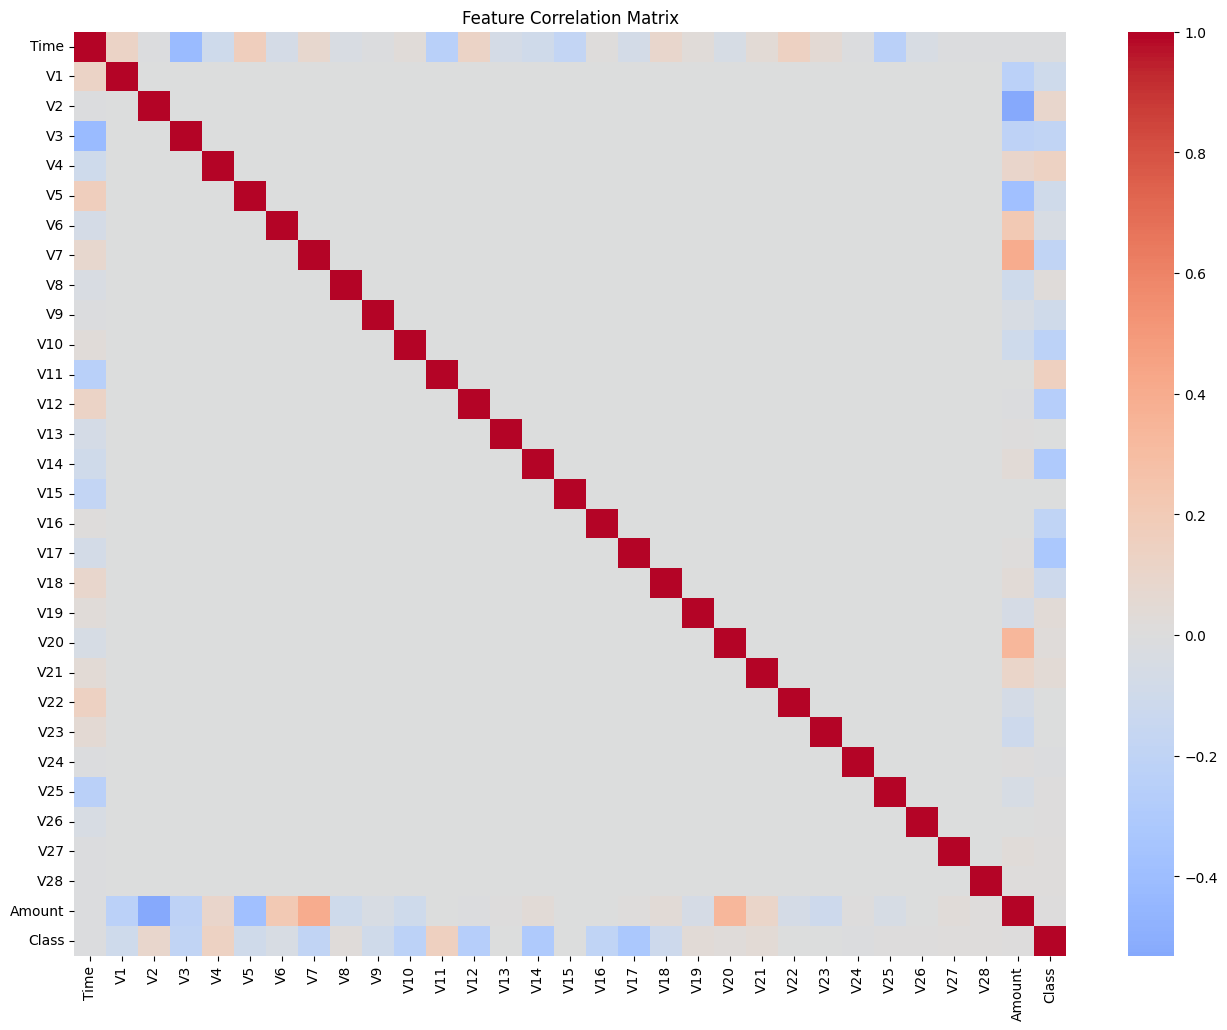

In [32]:
plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Matrix")

plt.show()

In [33]:
class_correlation = (
    df.corr()["Class"]
    .drop("Class")
    .sort_values()
)

print("Most negatively correlated features:")
print(class_correlation.head(5))

print("\nMost positively correlated features:")
print(class_correlation.tail(5))

Most negatively correlated features:
V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
Name: Class, dtype: float64

Most positively correlated features:
V19    0.034783
V21    0.040413
V2     0.091289
V4     0.133447
V11    0.154876
Name: Class, dtype: float64


In [34]:
fraud_stats = df[df["Class"] == 1].describe().T

fraud_stats

,count,mean,std,min,25%,50%,75%,max
Time,492.0,80746.806911,47835.365138,406.000000,41241.500000,75568.500000,128483.000000,170348.000000
V1,492.0,-4.771948,6.783687,-30.552380,-6.036063,-2.342497,-0.419200,2.132386
V2,492.0,3.623778,4.291216,-8.402154,1.188226,2.717869,4.971257,22.057729
V3,492.0,-7.033281,7.110937,-31.103685,-8.643489,-5.075257,-2.276185,2.250210
V4,492.0,4.542029,2.873318,-1.313275,2.373050,4.177147,6.348729,12.114672
V5,492.0,-3.151225,5.372468,-22.105532,-4.792835,-1.522962,0.214562,11.095089
V6,492.0,-1.397737,1.858124,-6.406267,-2.501511,-1.424616,-0.413216,6.474115
V7,492.0,-5.568731,7.206773,-43.557242,-7.965295,-3.034402,-0.945954,5.802537
V8,492.0,0.570636,6.797831,-41.044261,-0.195336,0.621508,1.764879,20.007208
V9,492.0,-2.581123,2.500896,-13.434066,-3.872383,-2.208768,-0.787850,3.353525


In [35]:
genuine_stats = df[df["Class"] == 0].describe().T

genuine_stats

,count,mean,std,min,25%,50%,75%,max
Time,284315.0,94838.202258,47484.015786,0.000000,54230.000000,84711.000000,139333.000000,172792.000000
V1,284315.0,0.008258,1.929814,-56.407510,-0.917544,0.020023,1.316218,2.454930
V2,284315.0,-0.006271,1.636146,-72.715728,-0.599473,0.064070,0.800446,18.902453
V3,284315.0,0.012171,1.459429,-48.325589,-0.884541,0.182158,1.028372,9.382558
V4,284315.0,-0.007860,1.399333,-5.683171,-0.850077,-0.022405,0.737624,16.875344
V5,284315.0,0.005453,1.356952,-113.743307,-0.689398,-0.053457,0.612181,34.801666
V6,284315.0,0.002419,1.329913,-26.160506,-0.766847,-0.273123,0.399619,73.301626
V7,284315.0,0.009637,1.178812,-31.764946,-0.551442,0.041138,0.571019,120.589494
V8,284315.0,-0.000987,1.161283,-73.216718,-0.208633,0.022041,0.326200,18.709255
V9,284315.0,0.004467,1.089372,-6.290730,-0.640412,-0.049964,0.598230,15.594995


In [36]:
comparison = pd.DataFrame({
    "Genuine Mean": genuine.mean(),
    "Fraud Mean": fraud.mean(),
    "Genuine Std": genuine.std(),
    "Fraud Std": fraud.std()
})

comparison

,Genuine Mean,Fraud Mean,Genuine Std,Fraud Std
Time,94838.202258,80746.806911,47484.015786,47835.365138
V1,0.008258,-4.771948,1.929814,6.783687
V2,-0.006271,3.623778,1.636146,4.291216
V3,0.012171,-7.033281,1.459429,7.110937
V4,-0.007860,4.542029,1.399333,2.873318
V5,0.005453,-3.151225,1.356952,5.372468
V6,0.002419,-1.397737,1.329913,1.858124
V7,0.009637,-5.568731,1.178812,7.206773
V8,-0.000987,0.570636,1.161283,6.797831
V9,0.004467,-2.581123,1.089372,2.500896


In [37]:
df.groupby("Class")["Amount"].agg([
    "count",
    "mean",
    "median",
    "std",
    "min",
    "max"
])

,count,mean,median,std,min,max
Class,,,,,,
0,284315,88.291022,22.00,250.105092,0.0,25691.16
1,492,122.211321,9.25,256.683288,0.0,2125.87


# Observations

After exploring the dataset, we observed:

1. The dataset contains 284,807 transactions.

2. The target variable is `Class`.

3. `Class = 0` represents genuine transactions.

4. `Class = 1` represents fraudulent transactions.

5. Fraudulent transactions represent a very small proportion of
   the complete dataset.

6. Therefore, the dataset is highly imbalanced.

7. The features `V1` to `V28` are anonymized features.

8. `Time` represents the transaction time.

9. `Amount` represents the transaction amount.

10. Different features have different distributions and scales.

11. Correlation analysis shows that some features have stronger
    relationships with the target than others.

12. Further preprocessing is required before training the machine
    learning models.

13. Class imbalance needs to be handled carefully during the
    model-training stage.